# Medical Insurance Cost Prediction 

 Problem Statement :To analyze the factors affecting medical insurance charges to predict insurance costs.

Aim: To accurately predicts medical insurance charges using the given dataset.

step 1

Importing libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

step 2

loading dataset

In [3]:
df=pd.read_csv('insurance.csv')

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


step 3 : Data understanding

In [5]:
print(df.shape)

(1338, 7)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


no missing value in any column

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


step 4: data cleansing

In [8]:
df['sex'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [9]:
df['smoker'].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [10]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [11]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


checking missing value

In [12]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

no missing values

In [13]:
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


check duplicate values

In [14]:
df.head(6)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [15]:
df.duplicated().sum()

np.int64(1)

In [16]:
df.drop_duplicates(inplace=True)

## Exploratory Data Analysis  & Data Visualization

In [17]:
Gender_count=df['sex'].value_counts()
Gender_count

sex
male      675
female    662
Name: count, dtype: int64

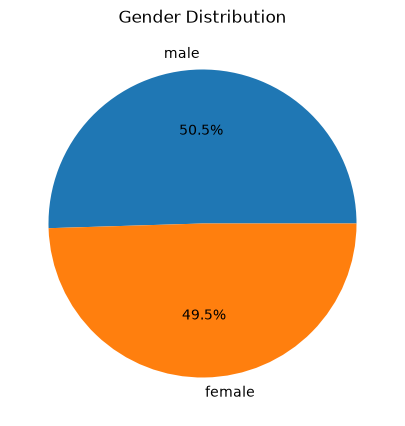

In [18]:
plt.figure(figsize=(10,5))
plt.pie(Gender_count,labels=Gender_count.index,autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

In [19]:
Gender_count

sex
male      675
female    662
Name: count, dtype: int64

In [20]:
smoker_count=df['smoker'].value_counts()
smoker_count

smoker
no     1063
yes     274
Name: count, dtype: int64

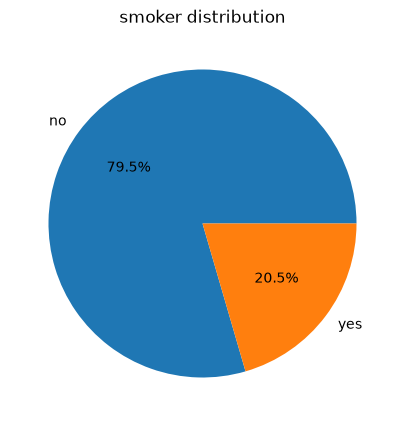

In [21]:
plt.figure(figsize=(10,5))
plt.pie(smoker_count,labels=smoker_count.index,autopct="%1.1f%%")
plt.title("smoker distribution")
plt.show()

In [22]:
region_count=df['region'].value_counts()
region_count

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

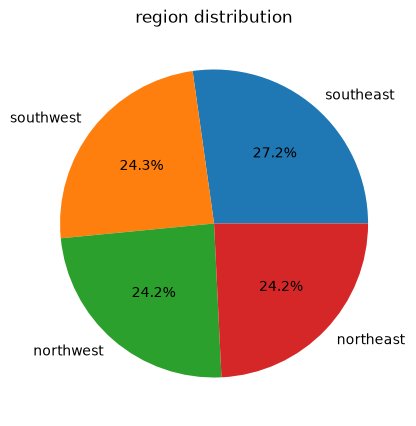

In [23]:
plt.figure(figsize=(10,5))
plt.pie(region_count,labels=region_count.index,autopct="%1.1f%%")
plt.title("region distribution")
plt.show()

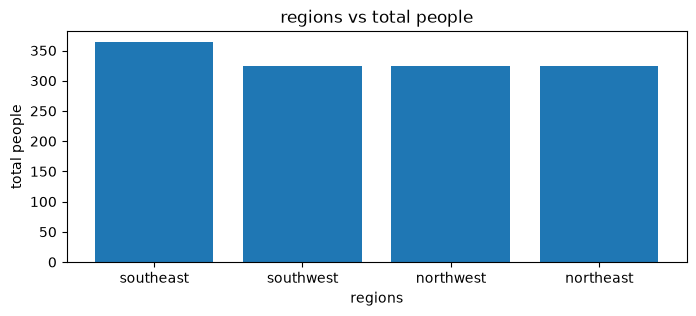

In [24]:
plt.figure(figsize=(8,3))
plt.bar(region_count.index,region_count.values)
plt.title("regions vs total people")
plt.xlabel("regions")
plt.ylabel("total people")
plt.show()

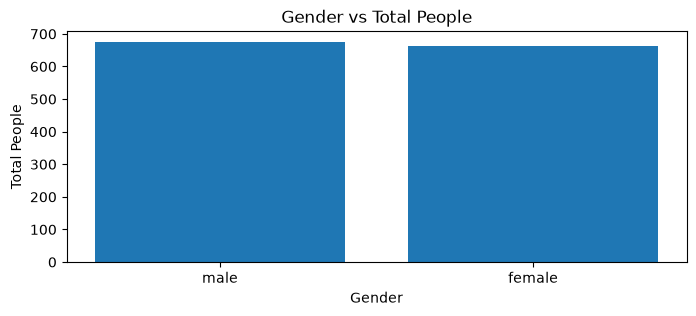

In [29]:
gender_count = df['sex'].value_counts()

plt.figure(figsize=(8,3))
plt.bar(gender_count.index, gender_count.values)

plt.title("Gender vs Total People")
plt.xlabel("Gender")
plt.ylabel("Total People")

plt.show()



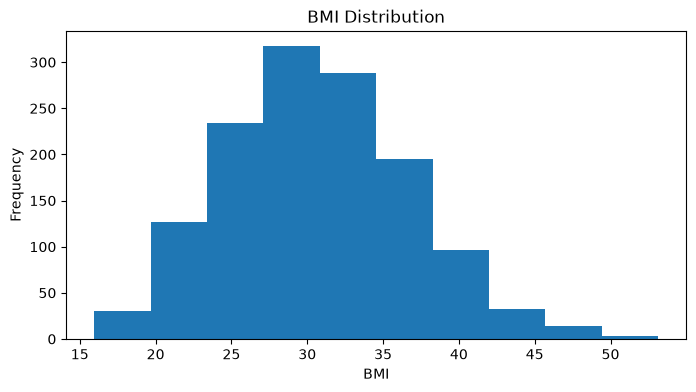

In [26]:
plt.figure(figsize=(8,4))
plt.hist(df['bmi'])

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

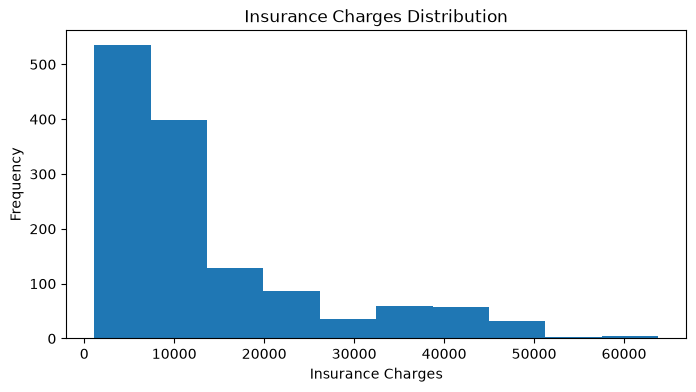

In [27]:
plt.figure(figsize=(8,4))
plt.hist(df['charges'])

plt.title("Insurance Charges Distribution")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.show()

Model Building

In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
le = LabelEncoder()

In [32]:
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [33]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [34]:
import seaborn as sns

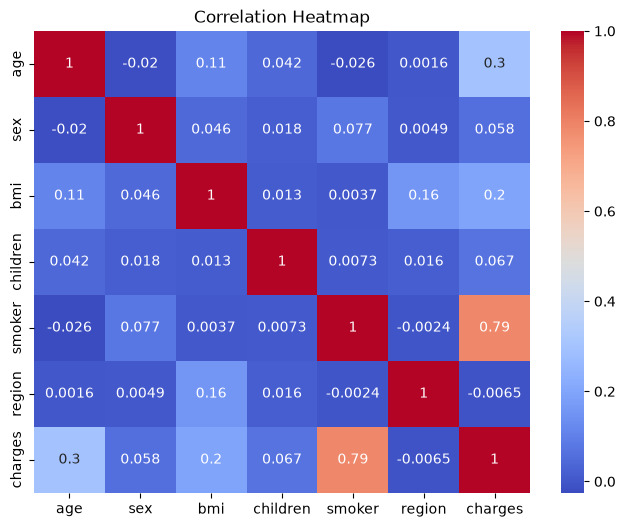

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Feature Selection


In [36]:
X = df.drop('charges', axis=1)
y = df['charges']

Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split



In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 248.76, -99.7 , 312.61, 534.12,23052.15, -237.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.105e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


Prediction

In [40]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Model Evaluation

In [45]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


Mean Absolute Error: 4182.353155288297
Mean Squared Error: 35493102.61165053


In [41]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8068466322629111


Actual vs Predicted

In [44]:
prediction = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

prediction.head()

,Actual,Predicted
900,8688.85885,8080.450186
1064,5708.86700,5592.871120
1256,11436.73815,14378.298655
298,38746.35510,31731.819541
237,4463.20510,9158.356944


Conclusion

The insurance dataset was successfully loaded and analyzed.

Data preprocessing was performed by handling duplicates and encoding categorical variables.

 A Linear Regression model was trained to predict insurance charges.


The model achieved an R² Score of approximately 0.81, indicating good prediction performance.